In [25]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

In [26]:
# 1. Load dataset and basic setup
DATA_PATH = 'Loan_default.csv'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [27]:
# Load data

df = pd.read_csv(DATA_PATH)
print('Dataset loaded successfully')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())

Dataset loaded successfully
Shape: (255347, 18)

First 5 rows:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorce

In [28]:
# 2. Understanding of dataset

print('\nColumn Names:')
print(df.columns.tolist())

print('\nDataset Info:')
print(df.info())

print('\nData Types:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nMissing Value Percentages:')
print((df.isnull().sum() / len(df) * 100).round(2))

print('\nDescriptive Statistics:')
print(df.describe(include='all').T)


Column Names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  Em

In [29]:
# 3. Duplicate check

full_duplicates = df.duplicated().sum()
loanid_duplicates = df['LoanID'].duplicated().sum() if 'LoanID' in df.columns else 0

print('\nFull duplicate rows:', full_duplicates)
print('Duplicate LoanID values:', loanid_duplicates)

if full_duplicates > 0:
    df = df.drop_duplicates().copy()
    print('Duplicates removed. New shape:', df.shape)


Full duplicate rows: 0
Duplicate LoanID values: 0


In [30]:
# 4. Separate variable types

target_col = 'Default'
id_col = 'LoanID'

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]

print('\nNumeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Numeric columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical columns: ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [31]:
# 5. Data cleansing and transformation plan

raw_df = df.copy()

# Outlier summary using IQR

outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, outliers])

outlier_df = pd.DataFrame(outlier_summary, columns=['feature', 'Q1', 'Q3', 'lower_bound', 'upper_bound', 'outlier_count'])

print('\nOutlier Summary:')
print(outlier_df)


Outlier Summary:
          feature        Q1         Q3  lower_bound  upper_bound  \
0             Age     31.00      56.00        -6.50        93.50   
1          Income  48825.50  116219.00    -52264.75    217309.25   
2      LoanAmount  66156.00  188985.00   -118087.50    373228.50   
3     CreditScore    437.00     712.00        24.50      1124.50   
4  MonthsEmployed     30.00      90.00       -60.00       180.00   
5  NumCreditLines      2.00       3.00         0.50         4.50   
6    InterestRate      7.77      19.25        -9.45        36.47   
7        LoanTerm     24.00      48.00       -12.00        84.00   
8        DTIRatio      0.30       0.70        -0.30         1.30   

   outlier_count  
0              0  
1              0  
2              0  
3              0  
4              0  
5              0  
6              0  
7              0  
8              0  


In [32]:
# Outlier treatment by clipping

df_clean = df.copy()
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower, upper)


Univariate Analysis - Numeric Summary
                   count           mean           std      min       25%  \
Age             255347.0      43.498306     14.990258     18.0     31.00   
Income          255347.0   82499.304597  38963.013729  15000.0  48825.50   
LoanAmount      255347.0  127578.865512  70840.706142   5000.0  66156.00   
CreditScore     255347.0     574.264346    158.903867    300.0    437.00   
MonthsEmployed  255347.0      59.541976     34.643376      0.0     30.00   
NumCreditLines  255347.0       2.501036      1.117018      1.0      2.00   
InterestRate    255347.0      13.492773      6.636443      2.0      7.77   
LoanTerm        255347.0      36.025894     16.969330     12.0     24.00   
DTIRatio        255347.0       0.500212      0.230917      0.1      0.30   

                      50%        75%       max  
Age                 43.00      56.00      69.0  
Income           82466.00  116219.00  149999.0  
LoanAmount      127556.00  188985.00  249999.0  
Cred

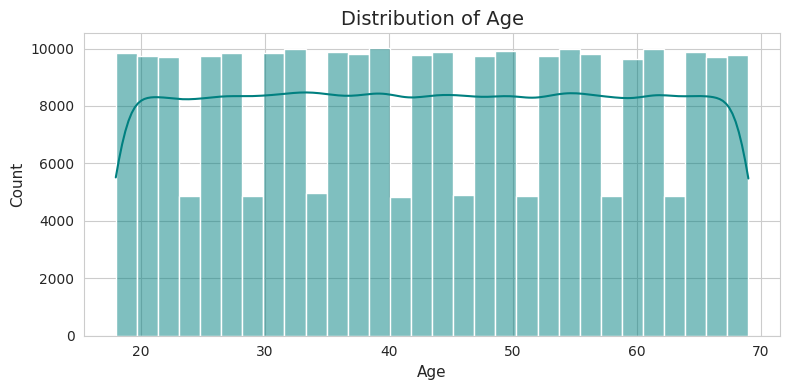

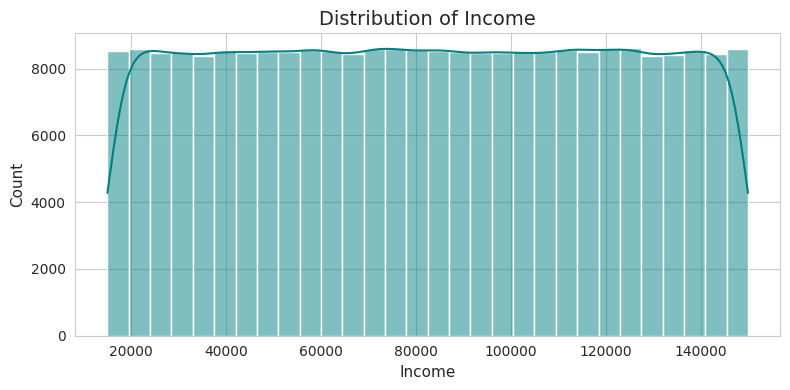

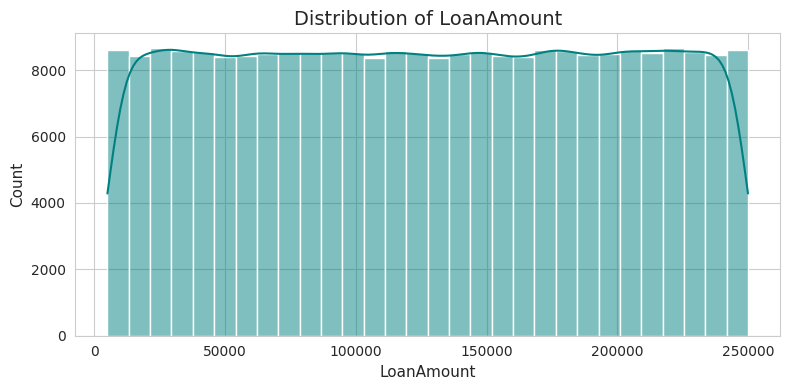

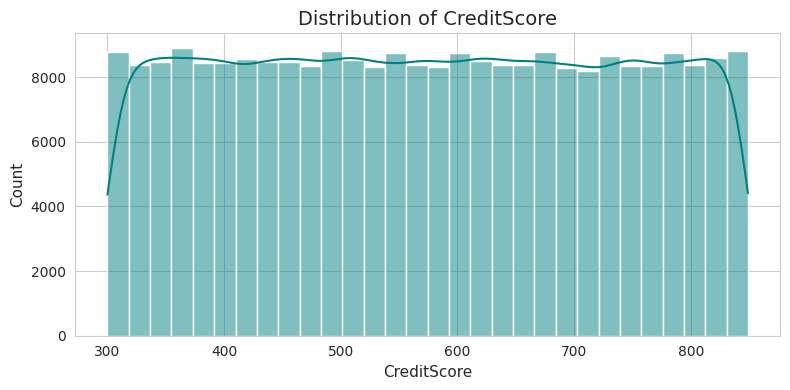

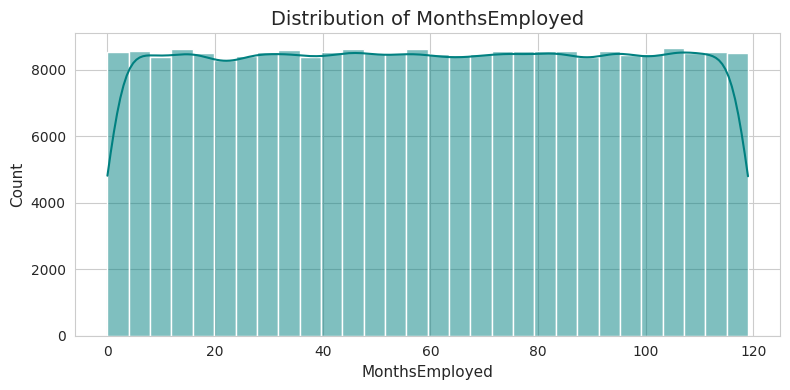

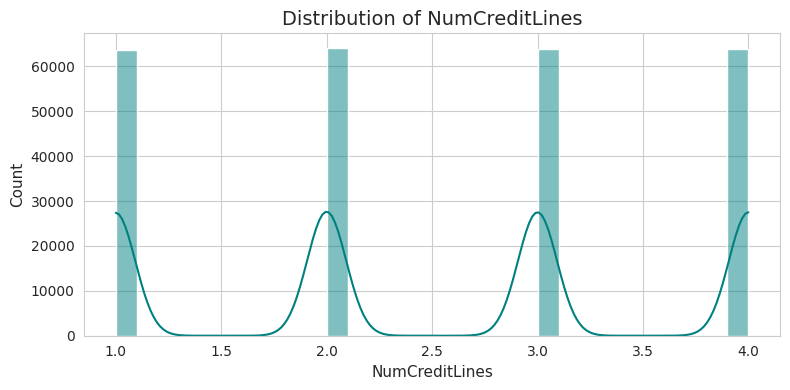

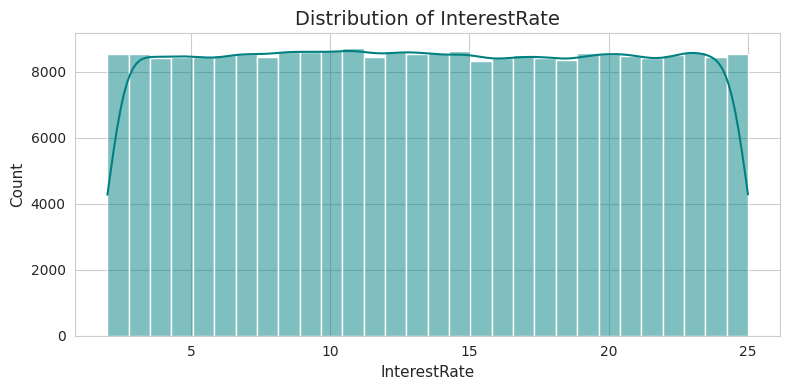

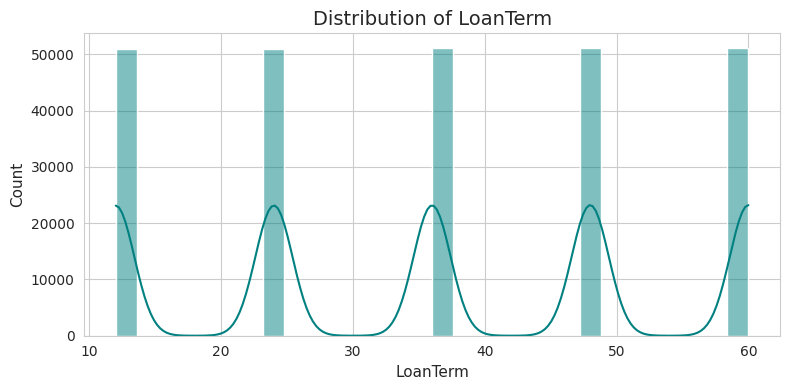

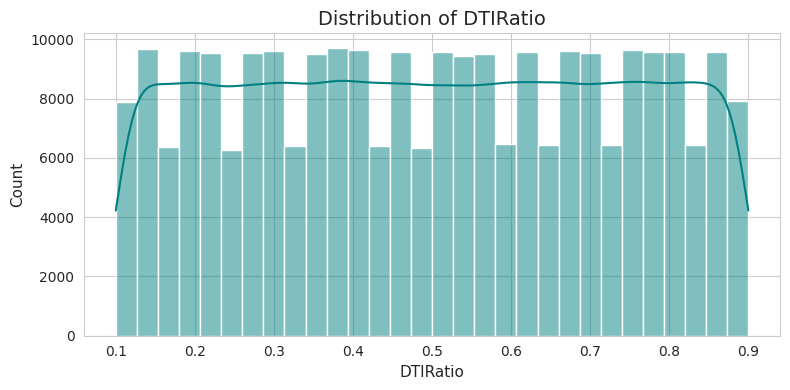

In [33]:
# 6. Univariate Analysis

print('\nUnivariate Analysis - Numeric Summary')
print(df_clean[numeric_cols].describe().T)

# Histograms for numeric variables
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[col], kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

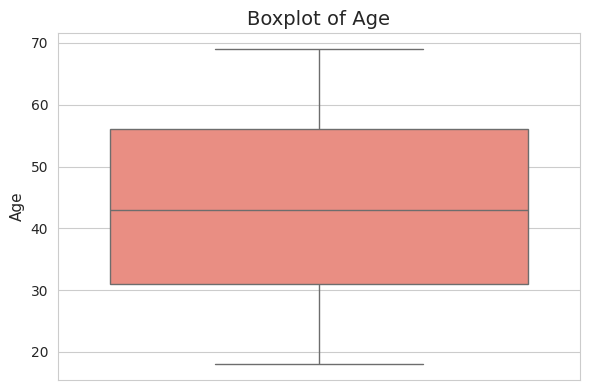

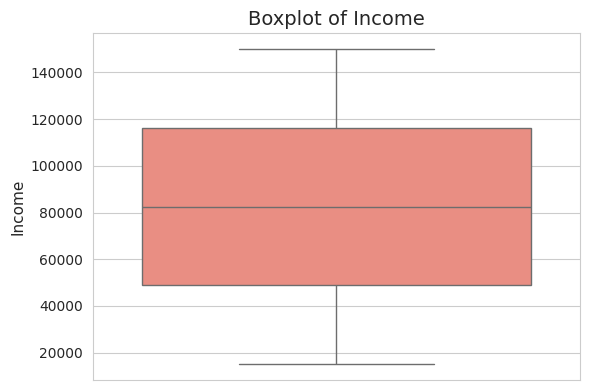

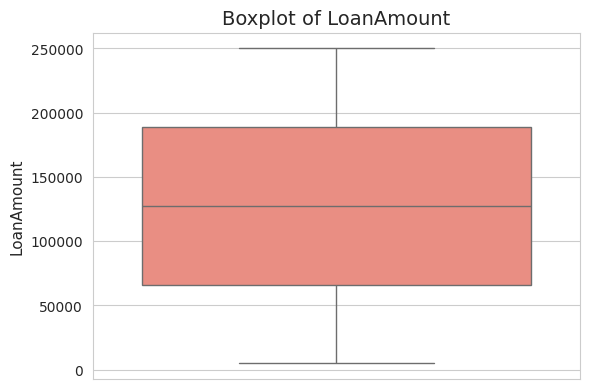

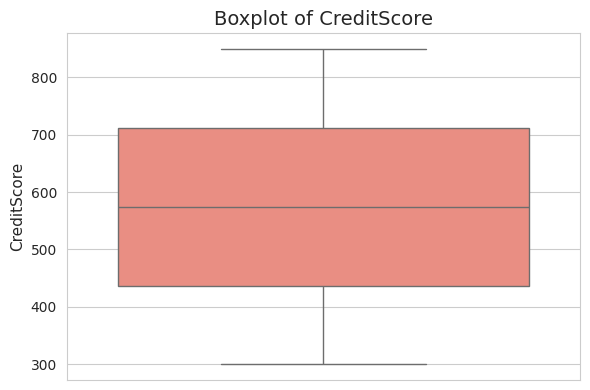

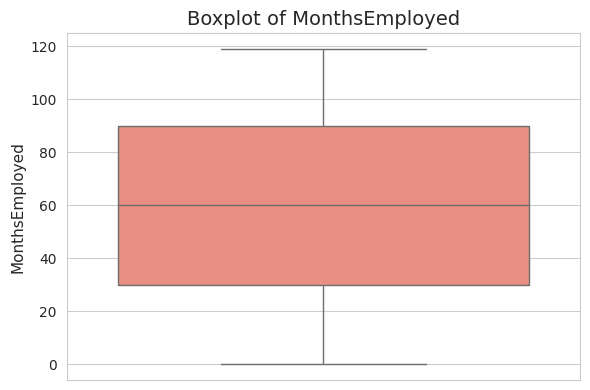

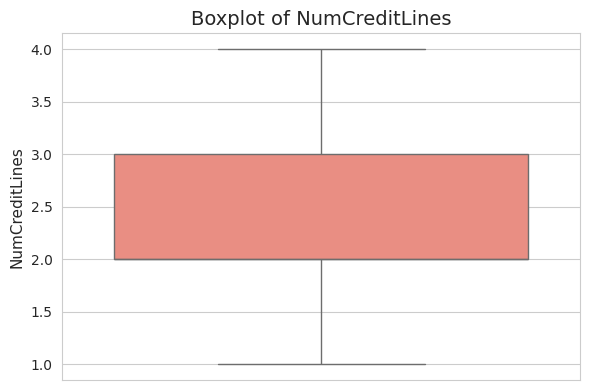

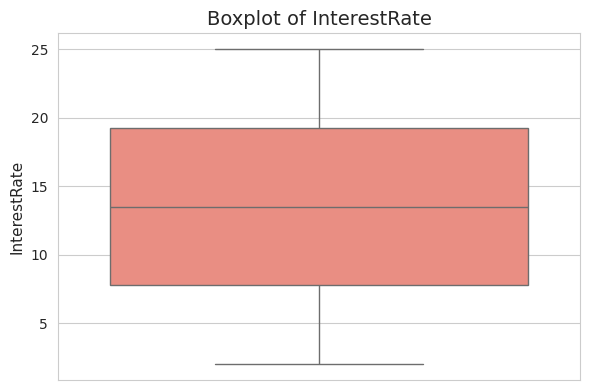

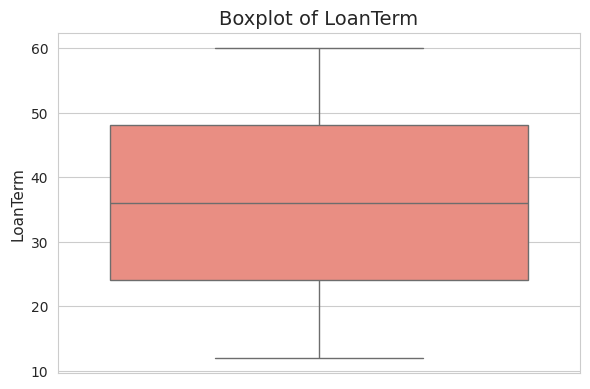

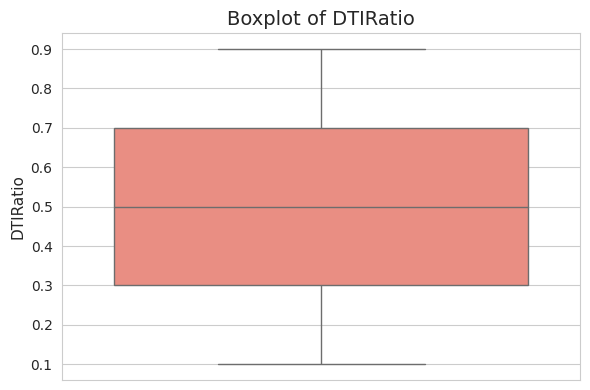

In [34]:
# Boxplots for numeric variables

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_clean[col], color='salmon')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()


Value counts for LoanID:
LoanID
ZTH91CGL0B    1
I38PQUQS96    1
HPSK72WA7R    1
QU29Z1EVQI    1
QXBHNXNA9X    1
P3UCIPJVTB    1
BLRBOJV956    1
FYGOB527WK    1
8KNPN8TX5I    1
Q8OXUYF0TI    1
Name: count, dtype: int64


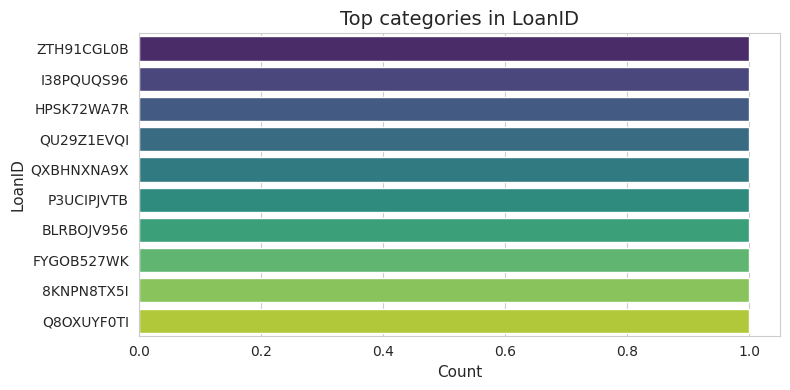


Value counts for Education:
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64


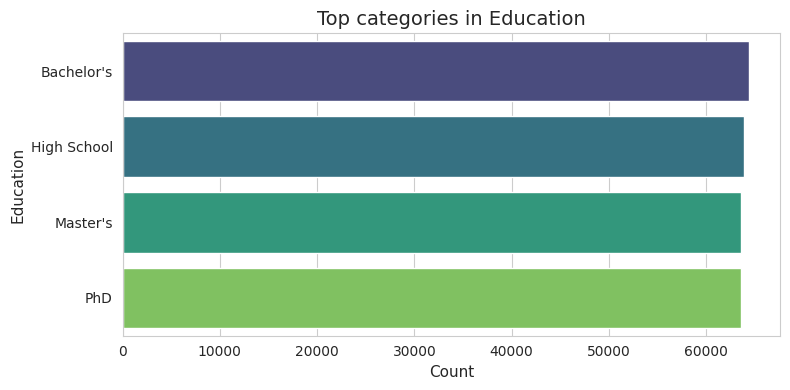


Value counts for EmploymentType:
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64


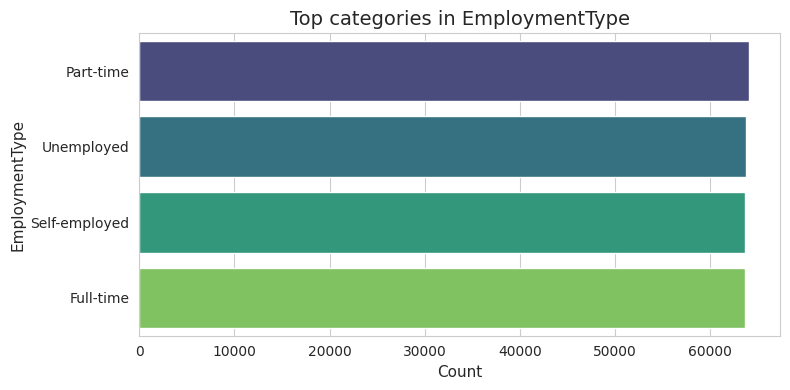


Value counts for MaritalStatus:
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64


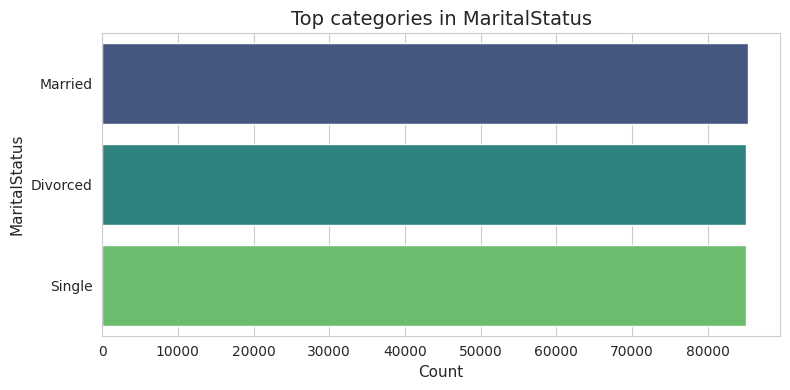


Value counts for HasMortgage:
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64


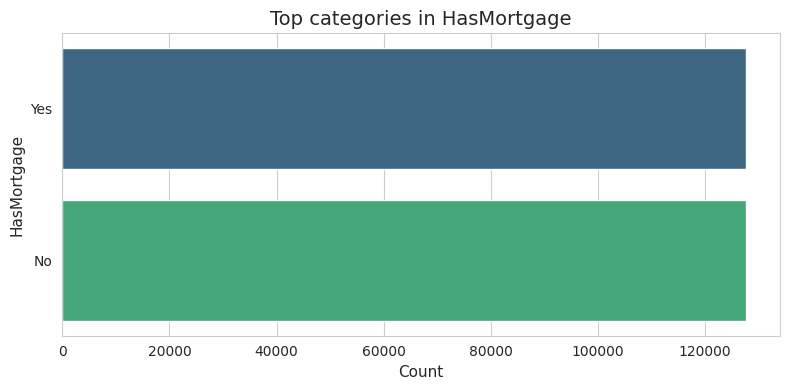


Value counts for HasDependents:
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64


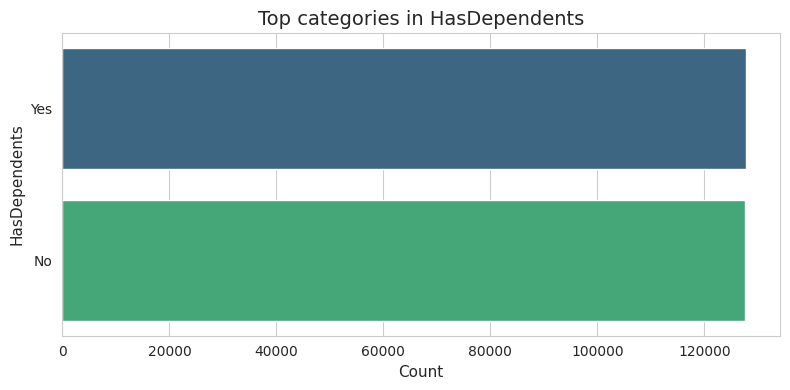


Value counts for LoanPurpose:
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64


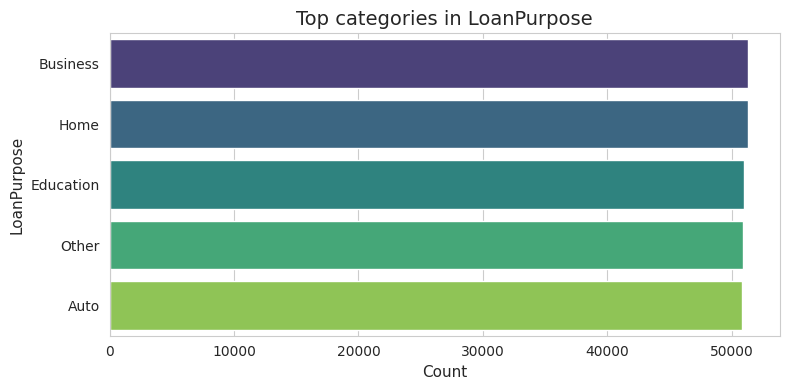


Value counts for HasCoSigner:
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


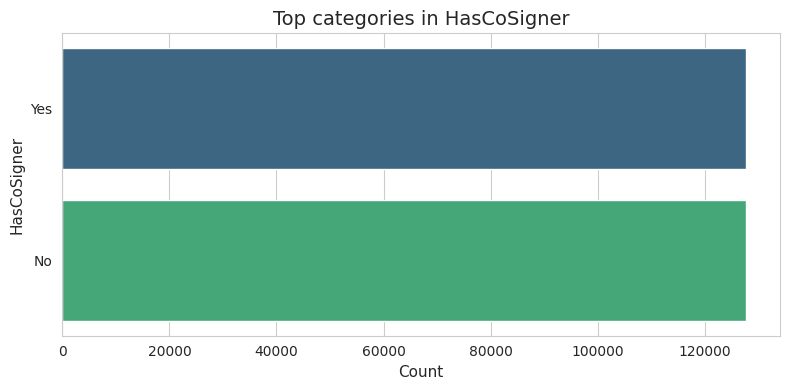

In [37]:
# Count plots for categorical variables

for col in categorical_cols:
    counts = df_clean[col].value_counts(dropna=False).head(10)

    print(f"\nValue counts for {col}:")
    print(counts)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index, palette='viridis')
    plt.title(f'Top categories in {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

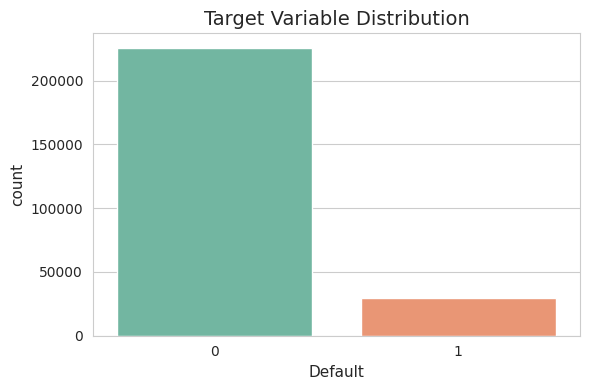

In [38]:
# Target distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df_clean, palette='Set2')
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.show()

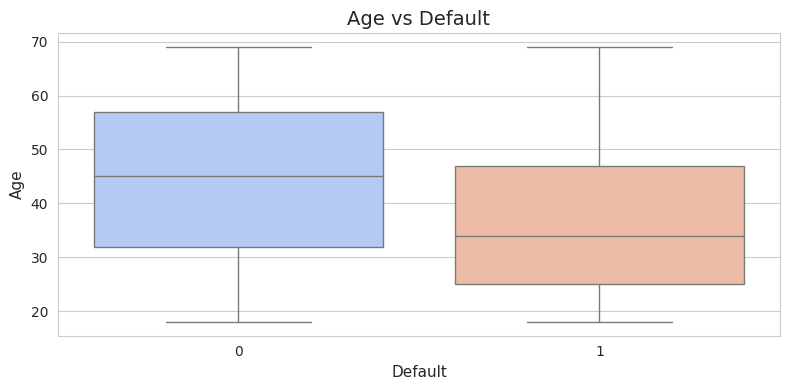

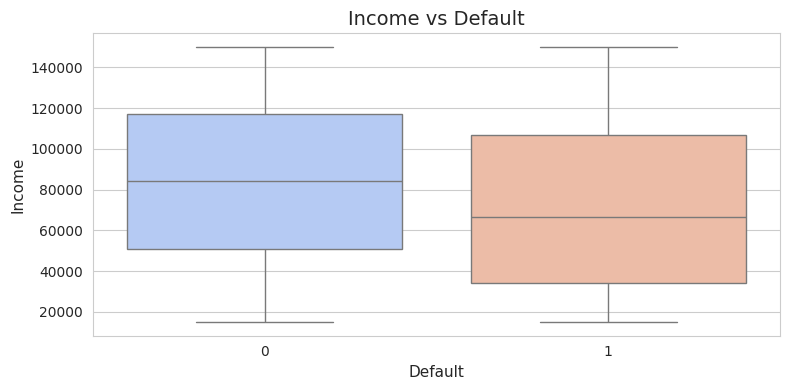

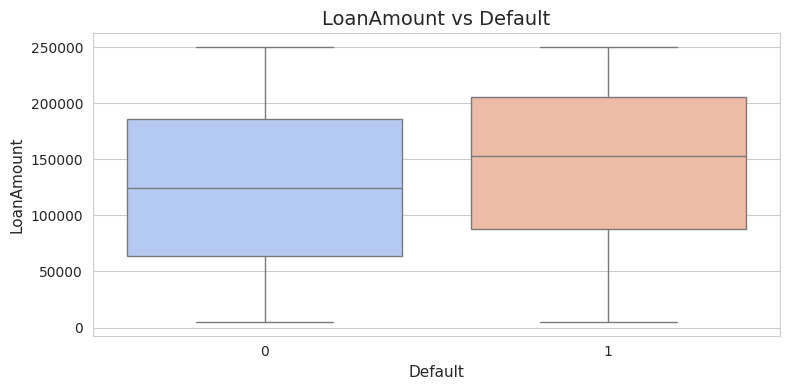

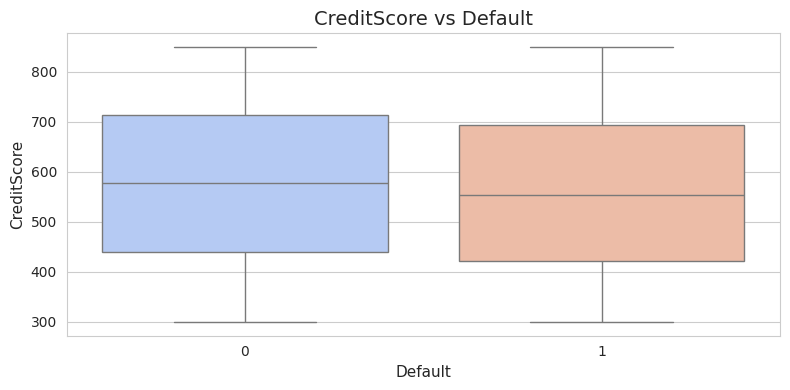

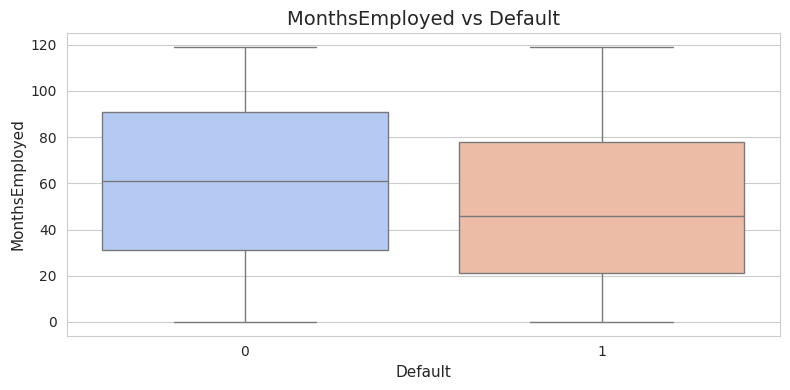

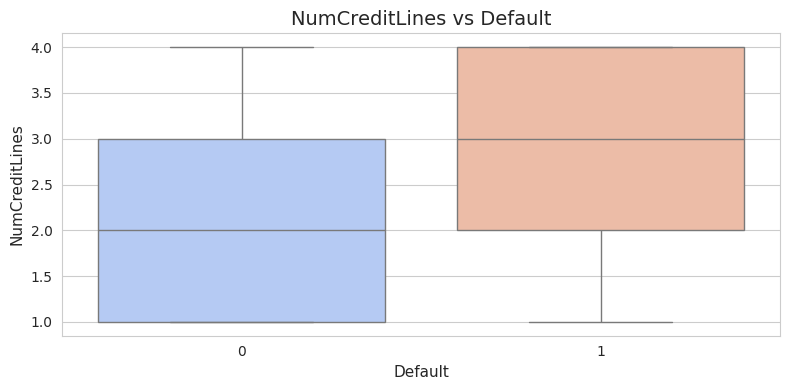

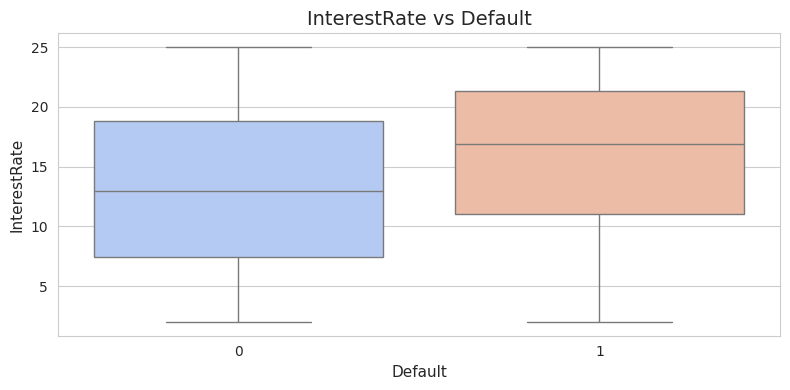

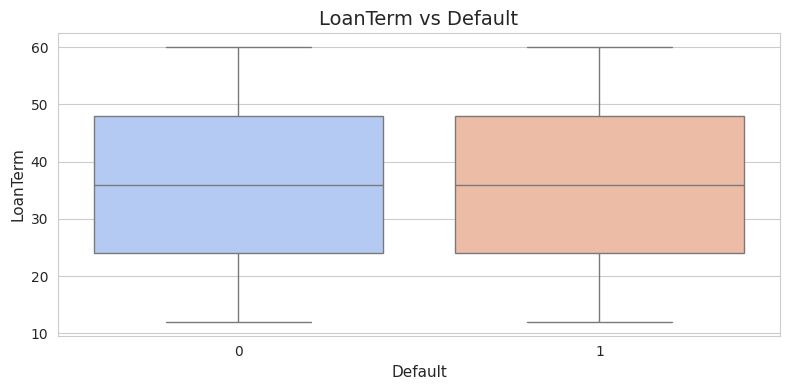

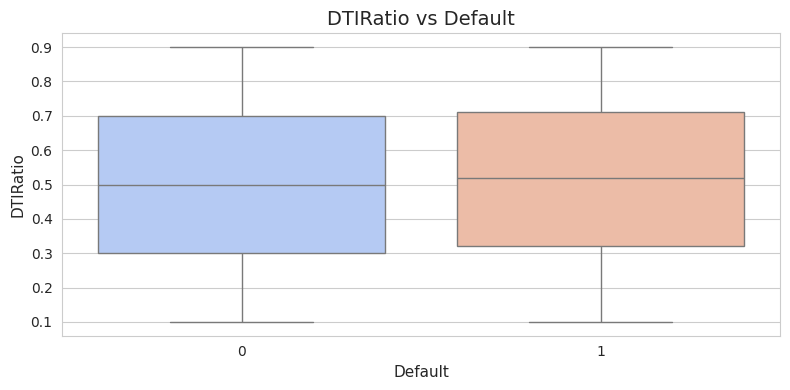

In [39]:
# 7. Bivariate Analysis

# Numeric vs target
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=target_col, y=col, data=df_clean, palette='coolwarm')
    plt.title(f'{col} vs {target_col}')
    plt.tight_layout()
    plt.show()


Column: LoanID | Unique categories: 255347
Skipped plot for LoanID because it has too many categories.

Column: Education | Unique categories: 4
Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64


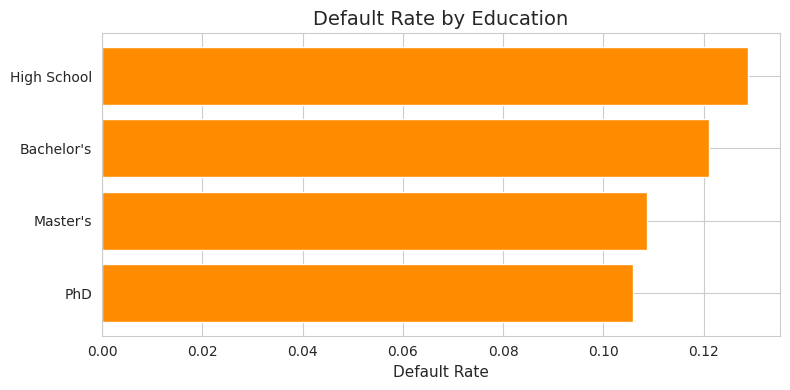


Column: EmploymentType | Unique categories: 4
EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64


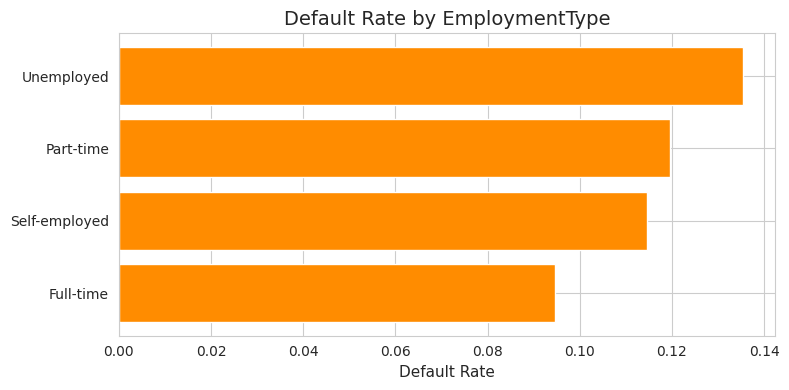


Column: MaritalStatus | Unique categories: 3
MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64


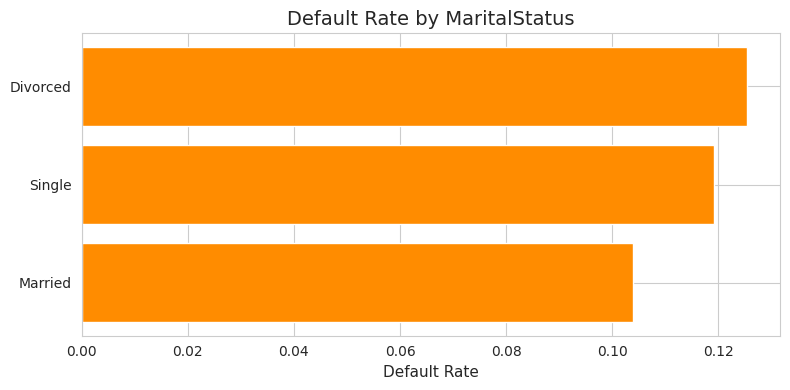


Column: HasMortgage | Unique categories: 2
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64


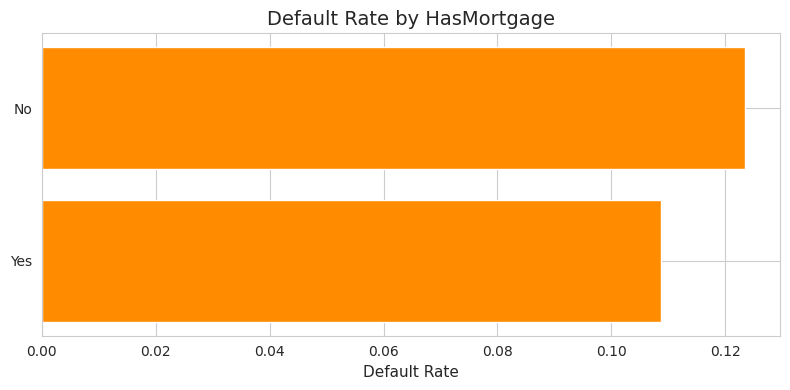


Column: HasDependents | Unique categories: 2
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64


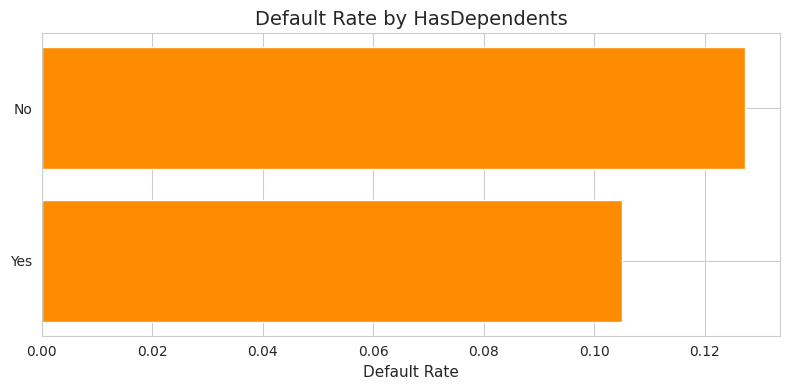


Column: LoanPurpose | Unique categories: 5
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64


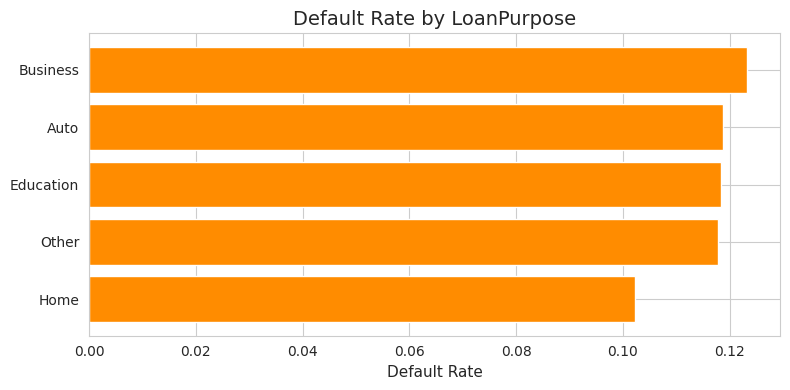


Column: HasCoSigner | Unique categories: 2
HasCoSigner
No     0.128661
Yes    0.103601
Name: Default, dtype: float64


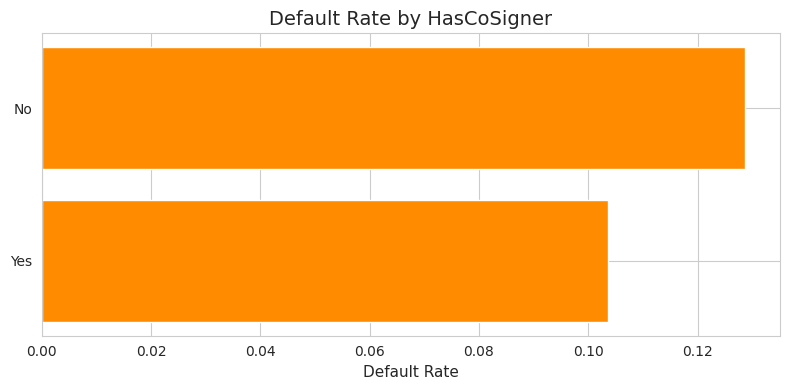

In [42]:
# Categorical vs Target

max_categories = 15

for col in categorical_cols:
    nunique = df_clean[col].nunique(dropna=False)

    print(f"\nColumn: {col} | Unique categories: {nunique}")

    if nunique > max_categories:
        print(f"Skipped plot for {col} because it has too many categories.")
        continue

    default_rate = (df_clean.groupby(col, observed=True, sort=False)[target_col].mean().sort_values(ascending=False))

    print(default_rate)

    plt.figure(figsize=(8, 4))
    plt.barh(default_rate.index.astype(str), default_rate.values, color="darkorange")
    plt.title(f"Default Rate by {col}")
    plt.xlabel("Default Rate")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

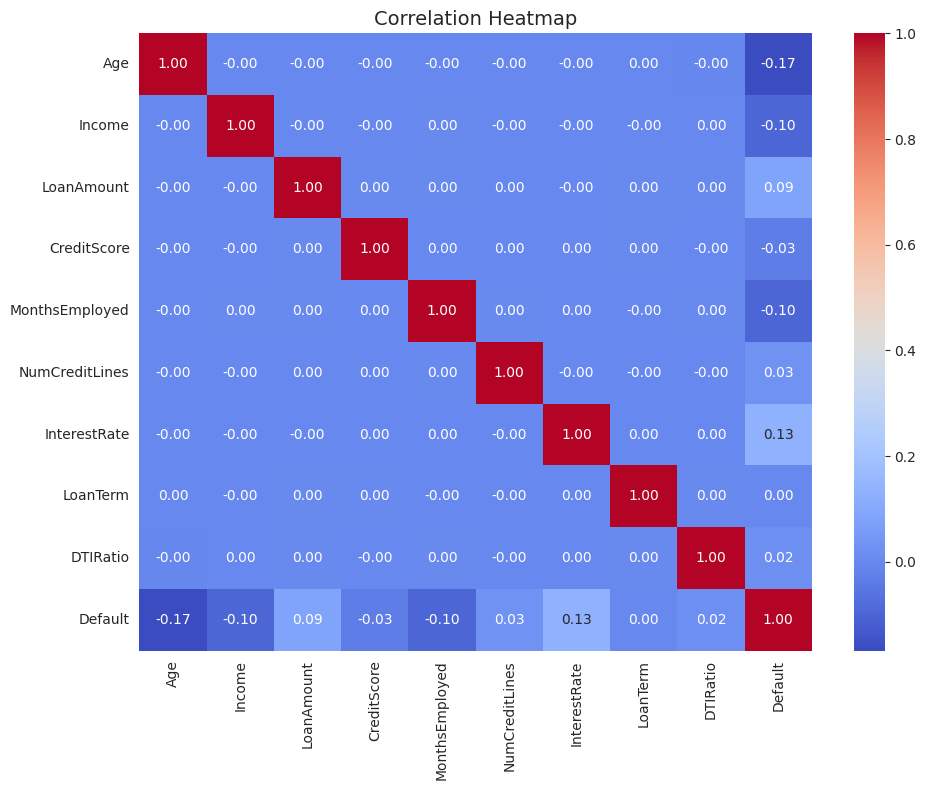

In [43]:
# 8. Multivariate Analysis

# Correlation heatmap

plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[numeric_cols + [target_col]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

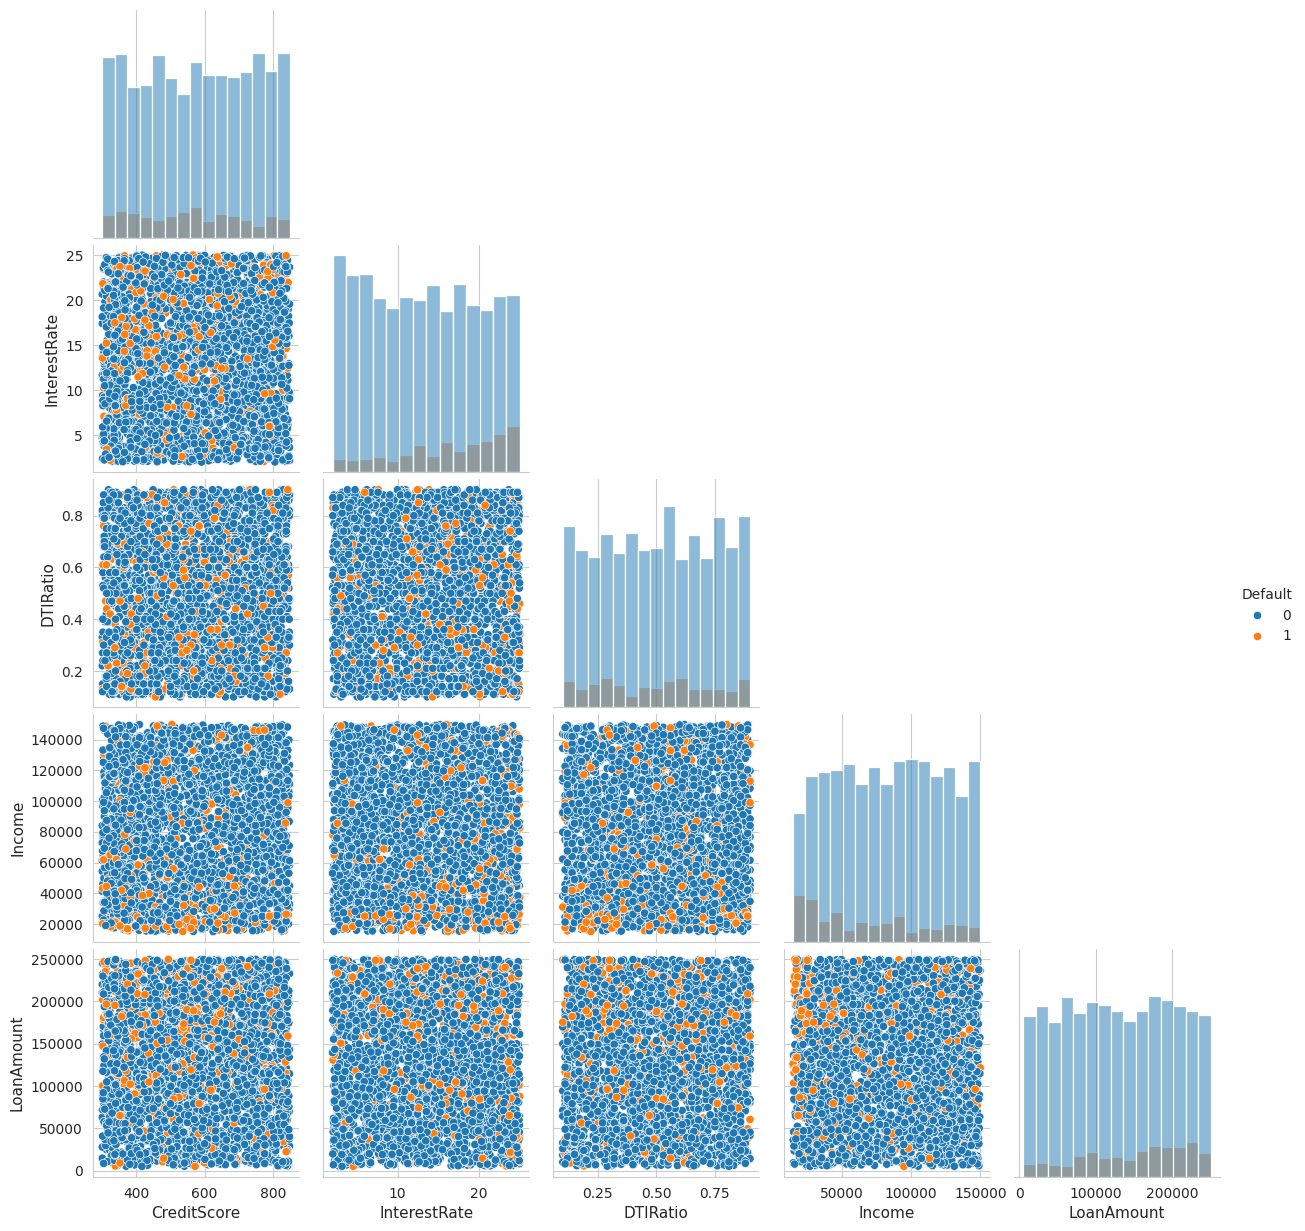

In [44]:
# Pairplot sample

sample_df = df_clean.sample(min(3000, len(df_clean)), random_state=42)
pairplot_cols = ['CreditScore', 'InterestRate', 'DTIRatio', 'Income', 'LoanAmount', target_col]
sns.pairplot(sample_df[pairplot_cols], hue=target_col, corner=True, diag_kind='hist')
plt.show()

In [45]:
# 9. Feature Engineering

model_df = df_clean.copy()

if id_col in model_df.columns:
    model_df = model_df.drop(columns=[id_col])

model_df['LoanToIncomeRatio'] = model_df['LoanAmount'] / model_df['Income'].replace(0, np.nan)
model_df['InterestLoanInteraction'] = model_df['InterestRate'] * model_df['LoanAmount']
model_df['EmploymentToAgeRatio'] = model_df['MonthsEmployed'] / model_df['Age'].replace(0, np.nan)

model_df['CreditScoreBand'] = pd.cut(model_df['CreditScore'],bins=[0, 580, 670, 740, 800, 900],labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent'],include_lowest=True)

model_df['DTIBand'] = pd.cut(model_df['DTIRatio'],bins=[0, 0.2, 0.35, 0.5, 0.75, 1.0],labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'],include_lowest=True)

model_df['HighDTIFlag'] = (model_df['DTIRatio'] >= model_df['DTIRatio'].median()).astype(int)
model_df['RiskIndex'] = (850 - model_df['CreditScore']) * model_df['InterestRate']

print('\nEngineered Data Sample:')
print(model_df.head())


Engineered Data Sample:
   Age  Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  \
0   56   85994       50587          520              80               4   
1   69   50432      124440          458              15               1   
2   46   84208      129188          451              26               3   
3   32   31713       44799          743               0               3   
4   60   20437        9139          633               8               4   

   InterestRate  LoanTerm  DTIRatio    Education  ... LoanPurpose HasCoSigner  \
0         15.23        36      0.44   Bachelor's  ...       Other         Yes   
1          4.81        60      0.68     Master's  ...       Other         Yes   
2         21.17        24      0.31     Master's  ...        Auto          No   
3          7.07        24      0.23  High School  ...    Business          No   
4          6.51        48      0.73   Bachelor's  ...        Auto          No   

  Default LoanToIncomeRatio InterestL

In [46]:
# 10. Prepare data for modeling

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

model_numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
model_categorical_cols = [c for c in X.columns if c not in model_numeric_cols]

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, model_numeric_cols),('cat', categorical_transformer, model_categorical_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print('\nTrain shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (204277, 23)
Test shape: (51070, 23)


In [48]:
# 11. Model Building

models = {'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced'),'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,class_weight='balanced_subsample'),'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

results = []
trained_models = {}

# Fit preprocessor once
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

for name, model in models.items():
    model.fit(X_train_pre, y_train)

    y_pred = model.predict(X_test_pre)
    y_prob = model.predict_proba(X_test_pre)[:, 1]

    metrics = {'Model': name,'Accuracy': accuracy_score(y_test, y_pred),'Precision': precision_score(y_test, y_pred),'Recall': recall_score(y_test, y_pred),'F1 Score': f1_score(y_test, y_pred),'ROC AUC': roc_auc_score(y_test, y_prob)}

    results.append(metrics)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)

print('\nModel Comparison Results:')
print(results_df)


Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.691012   0.228273  0.697521  0.343976  0.761547
2    Gradient Boosting  0.886352   0.606723  0.060867  0.110634  0.759286
1        Random Forest  0.885216   0.650655  0.025122  0.048377  0.736805


In [50]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'\nBest Model: {best_model_name}')

y_pred_best = best_model.predict(X_test_pre)
y_prob_best = best_model.predict_proba(X_test_pre)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best))


Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



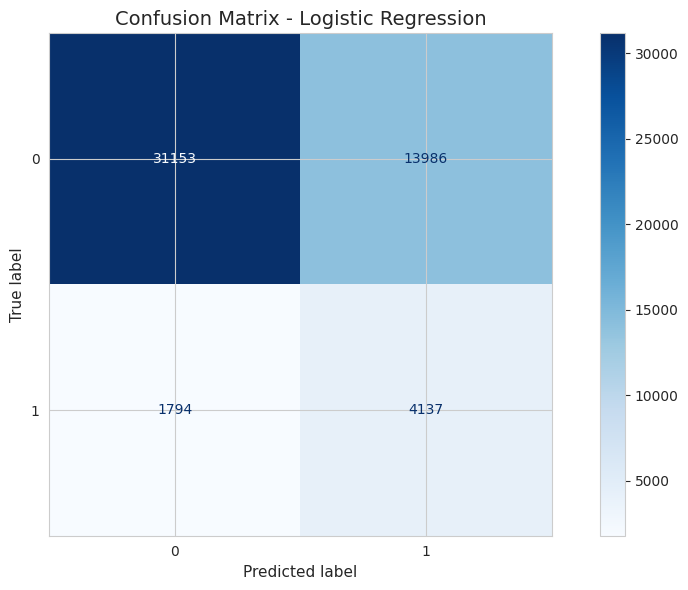

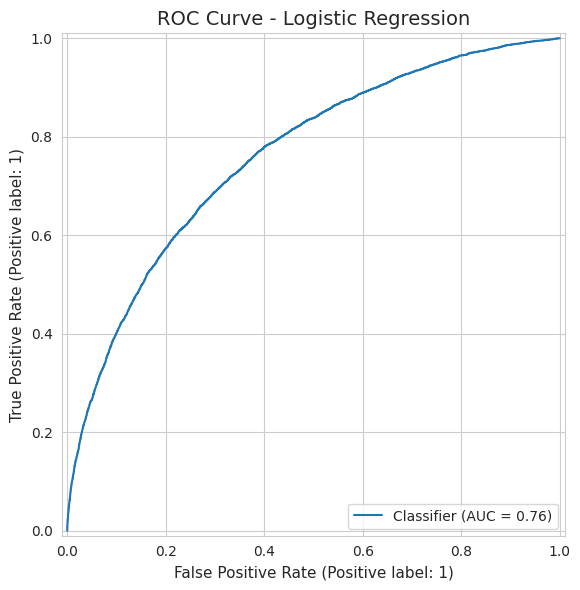

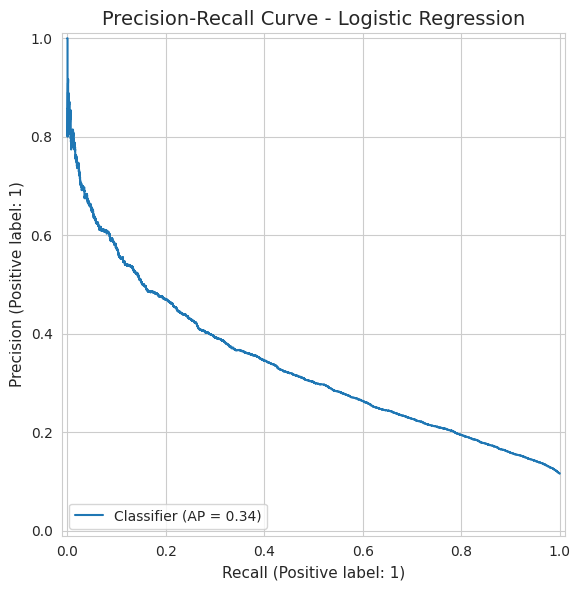

In [51]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

# ROC Curve

RocCurveDisplay.from_predictions(y_test, y_prob_best)
plt.title(f'ROC Curve - {best_model_name}')
plt.tight_layout()
plt.show()

# Precision-Recall Curve

PrecisionRecallDisplay.from_predictions(y_test, y_prob_best)
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.tight_layout()
plt.show()


Top Important Features:
                           Feature  Importance
0                         num__Age    0.083998
9           num__LoanToIncomeRatio    0.053806
6                num__InterestRate    0.048213
4              num__MonthsEmployed    0.023164
18   cat__EmploymentType_Full-time    0.003150
23      cat__MaritalStatus_Married    0.002650
35            cat__HasCoSigner_Yes    0.002392
5              num__NumCreditLines    0.002034
28          cat__HasDependents_Yes    0.001943
21  cat__EmploymentType_Unemployed    0.001833
26            cat__HasMortgage_Yes    0.001614
3                 num__CreditScore    0.001469
17              cat__Education_PhD    0.001075
32           cat__LoanPurpose_Home    0.000774
34             cat__HasCoSigner_No    0.000704


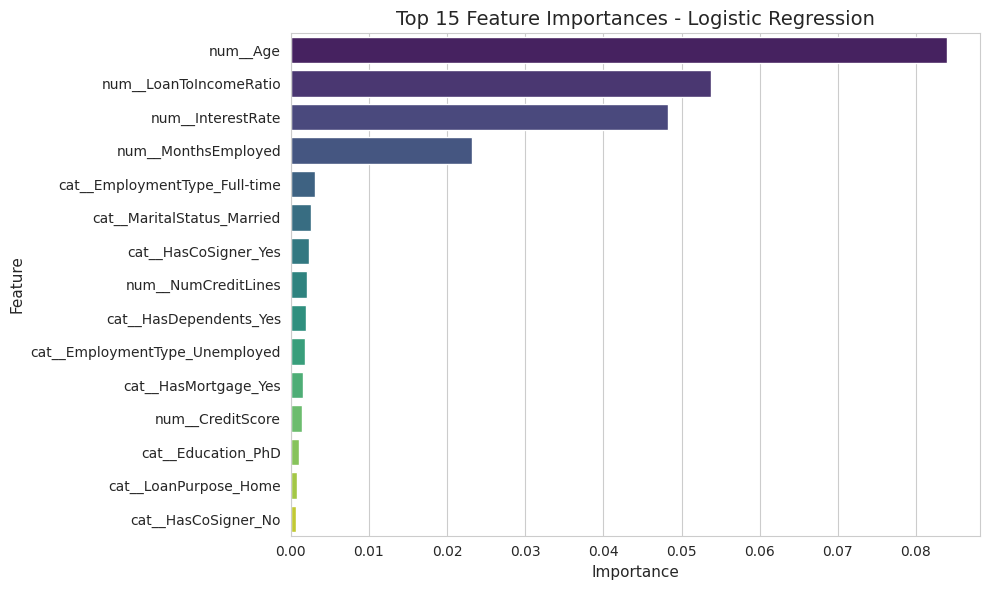

In [56]:
# 13. Feature Importance

sample_X = X_test.sample(min(10000, len(X_test)), random_state=42)
sample_y = y_test.loc[sample_X.index]

# Preprocess sample_X before passing it to permutation_importance

sample_X_pre = preprocessor.transform(sample_X)

perm_importance = permutation_importance(best_model,sample_X_pre,sample_y,n_repeats=5,random_state=42,scoring='roc_auc',n_jobs=-1)

# Get feature names after preprocessing

preprocessed_feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': preprocessed_feature_names,'Importance': perm_importance.importances_mean}).sort_values(by='Importance', ascending=False)

print('\nTop Important Features:')
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 15 Feature Importances - {best_model_name}')
plt.tight_layout()
plt.show()

In [57]:
# 14. Save useful outputs

results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison_results.csv'), index=False)
importance_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance_results.csv'), index=False)
outlier_df.to_csv(os.path.join(OUTPUT_DIR, 'outlier_summary.csv'), index=False)
model_df.head(1000).to_csv(os.path.join(OUTPUT_DIR, 'engineered_data_sample.csv'), index=False)

In [58]:
# 15. Business insights and recommendations

print('\nBusiness Insights:')
print('1. Credit quality, debt burden, interest rate, and affordability are likely core drivers of default risk.')
print('2. Ratio-based engineered features improve business interpretation of borrower stress.')
print('3. Segment-level default analysis supports better underwriting and manual review decisions.')
print('4. The selected model can be used as a decision-support system, not the only approval criterion.')

print('\nRecommendations:')
print('1. Use the best model as an early risk screening tool.')
print('2. Flag high-risk applicants for manual review.')
print('3. Tune classification threshold based on business cost of false positives vs false negatives.')
print('4. Monitor model drift and retrain periodically.')
print('5. Add explainability and fairness checks before production deployment.')

print('\nProject execution complete. Outputs saved inside outputs/ folder.')


Business Insights:
1. Credit quality, debt burden, interest rate, and affordability are likely core drivers of default risk.
2. Ratio-based engineered features improve business interpretation of borrower stress.
3. Segment-level default analysis supports better underwriting and manual review decisions.
4. The selected model can be used as a decision-support system, not the only approval criterion.

Recommendations:
1. Use the best model as an early risk screening tool.
2. Flag high-risk applicants for manual review.
3. Tune classification threshold based on business cost of false positives vs false negatives.
4. Monitor model drift and retrain periodically.
5. Add explainability and fairness checks before production deployment.

Project execution complete. Outputs saved inside outputs/ folder.
